# Random Forest Model Training and Final Holdout Evaluation

## Workflow

1. Import required libraries.
2. Load configuration from JSON.
3. Load and sort the prediction dataset.
4. Build the feature matrix and target vector.
5. Create the chronological train/development and holdout test split.
6. Define the race-level time-series split strategy.
7. Build the Random Forest estimator.
8. Run nested cross-validation on the train/development data.
9. Evaluate nested CV performance.
10. Analyze feature importance.
11. Inspect best hyperparameters per outer fold.
12. Train the final model and evaluate the untouched holdout test set.
13. Save the final model, hyperparameters, and metrics.


## Bibliography

- Bergstra, J., & Bengio, Y. (2012). Random Search for Hyper-Parameter Optimization. Journal of Machine Learning Research, 13, 281-305.


# 1. Import Required Libraries


In [166]:
import json
import pathlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    cohen_kappa_score,
)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

warnings.filterwarnings("ignore")


All hyperparameter choices, cross-validation settings, feature choices, dataset path, output paths, and the final holdout definition are stored in `json-parameters/random-forest/random_forest_optimization_params.json`. This keeps the experiment reproducible without hard-coding modeling choices inside the notebook.


In [167]:
# Resolve the repo root from the current notebook/script location.
start_path = pathlib.Path(__file__).resolve().parent if "__file__" in dir() else pathlib.Path.cwd().resolve()
for candidate in [start_path, *start_path.parents]:
    config_candidate = candidate / "json-parameters" / "random-forest" / "random_forest_optimization_params.json"
    if config_candidate.exists():
        REPO_ROOT = candidate
        CONFIG_PATH = config_candidate
        break
else:
    raise FileNotFoundError("Could not locate json-parameters/random-forest/random_forest_optimization_params.json")

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

print("Config loaded from:", CONFIG_PATH)
# print(json.dumps(config, indent=2))


Config loaded from: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/random-forest/random_forest_optimization_params.json


# 3-5. Load Data, Build Features, and Create the Final Holdout Split

The dataset path is read from `config["data"]["dataset_path"]`. Each row represents one driver in one race. The features include historical and rolling aggregates computed only from past races.

The notebook creates the chronological split before model selection:

| Portion | Purpose |
|---|---|
| Train/development seasons | Nested CV, hyperparameter tuning, and final fitting |
| Holdout test seasons | One final untouched evaluation of the final model |
| Excluded seasons | Removed from both training and final metrics, useful for incomplete seasons |

For the 2014 dataset, the current configuration uses `2014-2023` for train/development, `2024-2025` as the untouched holdout test period, and excludes incomplete `2026`.


In [168]:
dataset_path_cfg = config["data"].get("dataset_path", "dataset/outputs/prediction.csv")
DATA_PATH = pathlib.Path(dataset_path_cfg)
if not DATA_PATH.is_absolute():
    DATA_PATH = REPO_ROOT / DATA_PATH

df = pd.read_csv(DATA_PATH)

start_year = config["data"].get("start_year")
end_year = config["data"].get("end_year")
if start_year is not None:
    df = df[df["year"] >= int(start_year)].copy()
if end_year is not None:
    df = df[df["year"] <= int(end_year)].copy()
if df.empty:
    raise ValueError("Year filtering removed all rows from the dataset")

# ── Sort chronologically ────────────────────────────────────────────────────
sort_cols = config["data"]["sort_by"]          # ["year", "round"]
df = df.sort_values(sort_cols).reset_index(drop=True)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape after year filtering: {df.shape}")
if start_year is not None or end_year is not None:
    print(f"Year filter: start_year={start_year}, end_year={end_year}")
print(f"Chronological range: year {df['year'].min()} round {df['round'].min()}"
      f"  →  year {df['year'].max()} round {df['round'].max()}")
print("\nTarget distribution:")
print(df[config["data"]["target_column"]].value_counts())


Dataset path: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/dataset/outputs/prediction.csv
Dataset shape after year filtering: (2454, 41)
Chronological range: year 2021 round 1  →  year 2026 round 24

Target distribution:
target
no_points    1234
points        854
podium        366
Name: count, dtype: int64


In [169]:
# ── Build feature matrix X and label vector y ──────────────────────────────
target_col = config["data"]["target_column"]   # "target"
drop_cols = config["data"]["drop_columns"]      # identifiers / non-features
feature_cols = config["data"].get("feature_columns")
excluded_cols = config["data"].get("excluded_feature_columns", [])
categorical_cols = config["data"].get("categorical_feature_columns", [])


def validate_feature_list(name, cols, allow_none=False):
    if cols is None and allow_none:
        return
    if not isinstance(cols, list):
        raise TypeError(f"config['data']['{name}'] must be a list or null")
    duplicated = sorted({col for col in cols if cols.count(col) > 1})
    missing = sorted(set(cols) - set(df.columns))
    forbidden = sorted(set(cols) & set(drop_cols + [target_col]))
    if duplicated:
        raise ValueError(f"Duplicate columns in {name}: {duplicated}")
    if missing:
        raise ValueError(f"Columns in {name} not found in dataset: {missing}")
    if forbidden:
        raise ValueError(f"{name} includes non-feature columns: {forbidden}")


validate_feature_list("feature_columns", feature_cols, allow_none=True)
validate_feature_list("excluded_feature_columns", excluded_cols)
validate_feature_list("categorical_feature_columns", categorical_cols)

if feature_cols is not None:
    overlap = sorted(set(feature_cols) & set(excluded_cols))
    if overlap:
        raise ValueError(f"Columns cannot be both active and excluded: {overlap}")
    raw_X = df[feature_cols].copy()
    raw_feature_names = list(feature_cols)
else:
    cols_to_drop = drop_cols + [target_col] + excluded_cols
    raw_X = df.drop(columns=cols_to_drop)
    raw_feature_names = raw_X.columns.tolist()

missing_categorical = sorted(set(categorical_cols) - set(raw_feature_names))
if missing_categorical:
    raise ValueError(
        "categorical_feature_columns must be active model features. "
        f"Missing from feature set: {missing_categorical}"
    )

numeric_cols = [col for col in raw_feature_names if col not in categorical_cols]

# Encode target: no_points=0, podium=1, points=2  (alphabetical by default)
le = LabelEncoder()
y = le.fit_transform(df[target_col])

# ── Chronological final holdout split ──────────────────────────────────────
holdout_cfg = config["data"].get("holdout", {})
test_years = holdout_cfg.get("test_years", [2025])
exclude_years = holdout_cfg.get("exclude_years", [])

if not test_years:
    raise ValueError("config['data']['holdout']['test_years'] must contain at least one year")

test_years = sorted(int(year) for year in test_years)
exclude_years = sorted(int(year) for year in exclude_years)

test_mask = df["year"].isin(test_years)
exclude_mask = df["year"].isin(exclude_years)
train_dev_mask = ~(test_mask | exclude_mask)

if not train_dev_mask.any():
    raise ValueError("Holdout split leaves no rows for training/development")
if not test_mask.any():
    raise ValueError("Holdout split leaves no rows for final testing")
if set(test_years) & set(exclude_years):
    raise ValueError("The same year cannot be both a holdout test year and an excluded year")

train_max_date = pd.to_datetime(df.loc[train_dev_mask, "date"]).max()
test_min_date = pd.to_datetime(df.loc[test_mask, "date"]).min()
if train_max_date >= test_min_date:
    raise ValueError(
        "Holdout must be strictly after the training/development period. "
        f"Got train max date {train_max_date.date()} and test min date {test_min_date.date()}."
    )

train_dev_idx = np.flatnonzero(train_dev_mask.to_numpy())
holdout_idx = np.flatnonzero(test_mask.to_numpy())

raw_X_train_dev = raw_X.iloc[train_dev_idx].reset_index(drop=True)
y_train_dev = y[train_dev_idx]
df_train_dev = df.iloc[train_dev_idx].reset_index(drop=True)

raw_X_holdout = raw_X.iloc[holdout_idx].reset_index(drop=True)
y_holdout = y[holdout_idx]
df_holdout = df.iloc[holdout_idx].reset_index(drop=True)

# One-hot encode categorical ID columns so Random Forest does not treat them
# as ordered numeric quantities. The encoder is fit only on train/development
# rows; unseen holdout categories are ignored safely.
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

if categorical_cols:
    train_cat = onehot_encoder.fit_transform(raw_X_train_dev[categorical_cols].astype(str))
    holdout_cat = onehot_encoder.transform(raw_X_holdout[categorical_cols].astype(str))
    encoded_categorical_names = onehot_encoder.get_feature_names_out(categorical_cols).tolist()
else:
    train_cat = np.empty((len(raw_X_train_dev), 0))
    holdout_cat = np.empty((len(raw_X_holdout), 0))
    encoded_categorical_names = []

X_train_dev = pd.concat(
    [
        raw_X_train_dev[numeric_cols].reset_index(drop=True),
        pd.DataFrame(train_cat, columns=encoded_categorical_names),
    ],
    axis=1,
)
X_holdout = pd.concat(
    [
        raw_X_holdout[numeric_cols].reset_index(drop=True),
        pd.DataFrame(holdout_cat, columns=encoded_categorical_names),
    ],
    axis=1,
)
feature_names = X_train_dev.columns.tolist()
X = pd.concat([X_train_dev, X_holdout], axis=0, ignore_index=True)

print("Classes (encoded):", dict(enumerate(le.classes_)))
print("Raw feature count:", len(raw_feature_names))
print("Encoded feature count:", len(feature_names))
print("Categorical features one-hot encoded:")
for name in categorical_cols:
    print(f"  {name}")
print("\nRaw features used:")
for name in raw_feature_names:
    print(f"  {name}")
if excluded_cols:
    print("\nFeatures excluded by config:")
    for name in excluded_cols:
        print(f"  {name}")
print("\nEncoded feature dtypes:")
print(X_train_dev.dtypes.value_counts())

print("\nChronological holdout split:")
print(f"  Train/development years: {df_train_dev['year'].min()}-{df_train_dev['year'].max()}")
print(f"  Train/development rows : {len(df_train_dev)}")
print(f"  Train/development races: {df_train_dev['raceId'].nunique()}")
print(f"  Holdout test years     : {test_years}")
print(f"  Holdout test rows      : {len(df_holdout)}")
print(f"  Holdout test races     : {df_holdout['raceId'].nunique()}")
if exclude_years:
    print(f"  Excluded years         : {exclude_years}")
    print(f"  Excluded rows          : {int(exclude_mask.sum())}")
print("\nTrain/development target distribution:")
print(df_train_dev[target_col].value_counts())
print("\nHoldout target distribution:")
print(df_holdout[target_col].value_counts())


Classes (encoded): {0: 'no_points', 1: 'podium', 2: 'points'}
Raw feature count: 27
Encoded feature count: 27
Categorical features one-hot encoded:

Raw features used:
  grid
  qualifying_position
  grid_to_points_cutoff_delta
  qualifying_to_points_cutoff_delta
  driver_age
  driver_std_points_prev
  driver_std_position_prev
  constructor_std_points_prev
  constructor_std_position_prev
  points_this_season_prev
  driver_avg_position_last3
  driver_podium_rate_last3
  driver_podium_rate_last5
  driver_podium_rate_last10
  driver_points_avg_last3
  constructor_avg_position_last3
  driver_wins_at_circuit
  driver_avg_position_at_circuit
  teammate_h2h_avg_position_delta
  driver_dnf_rate_historical
  points_gap_to_leader
  constructor_change_flag
  days_since_last_race
  sprint_flag
  driver_seasons_in_f1
  is_home_race
  is_home_constructor_race

Features excluded by config:
  constructorId
  circuitId

Encoded feature dtypes:
float64    14
int64      13
Name: count, dtype: int64

Chron

# 6. Define the Race-Level Time-Series Split Strategy

## Why random k-fold is not appropriate

Standard `KFold(shuffle=True)` randomly assigns rows to folds. In this dataset, each row is one driver in one race, and many features for race t are computed from races t-1, t-2, and earlier. If later races enter training while earlier races are used for validation, the model-selection procedure can leak future information.

## Why row-level `TimeSeriesSplit` is also not enough

Plain `TimeSeriesSplit` preserves row order, but it splits by row count. Because each race has multiple driver rows, a fold boundary can cut through the middle of a race. That would put some drivers from the same race in training and the remaining drivers from the same race in validation.

## Strategy used here

The notebook first reserves the final chronological holdout test season. Then it applies `TimeSeriesSplit` only to the ordered list of training/development races and maps each race fold back to row indices. This keeps model selection chronological and keeps every race wholly inside either training or validation.


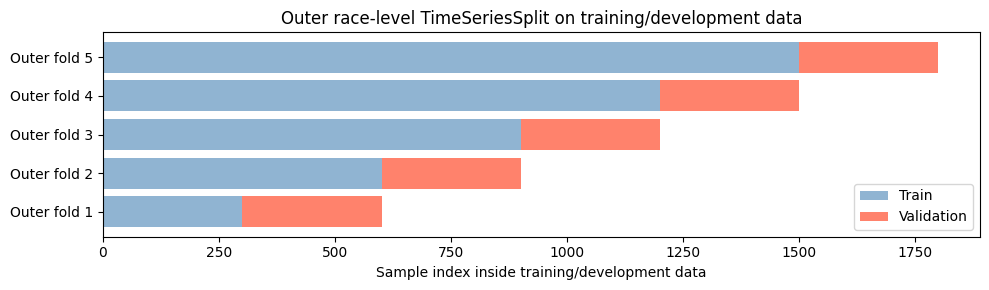

Fold 1: train races=15, validation races=15, race overlap=0
Fold 2: train races=30, validation races=15, race overlap=0
Fold 3: train races=45, validation races=15, race overlap=0
Fold 4: train races=60, validation races=15, race overlap=0
Fold 5: train races=75, validation races=15, race overlap=0


In [170]:
# ── Visualise the race-level TimeSeriesSplit structure ──────────────────────
outer_n_splits = config["cv"]["outer_n_splits"]
inner_n_splits = config["cv"]["inner_n_splits"]


def make_race_time_series_splits(df_source, n_splits):
    """Yield row indices from TimeSeriesSplit applied to whole races.

    TimeSeriesSplit normally splits by row count. Because this dataset has one
    row per driver, row-level splitting can put drivers from the same race in
    both train and test. This helper first splits unique races in date order,
    then maps those race folds back to row indices.
    """
    race_order = (
        df_source[["raceId", "date"]]
        .drop_duplicates()
        .sort_values("date")
        .reset_index(drop=True)
    )
    race_ids = race_order["raceId"].to_numpy()
    race_cv = TimeSeriesSplit(n_splits=n_splits)

    for train_race_idx, test_race_idx in race_cv.split(race_ids):
        train_races = set(race_ids[train_race_idx])
        test_races = set(race_ids[test_race_idx])

        train_idx = np.flatnonzero(df_source["raceId"].isin(train_races).to_numpy())
        test_idx = np.flatnonzero(df_source["raceId"].isin(test_races).to_numpy())

        yield train_idx, test_idx


outer_splits = list(make_race_time_series_splits(df_train_dev, outer_n_splits))

fig, axes = plt.subplots(1, 1, figsize=(10, 3))
for fold_idx, (train_idx, test_idx) in enumerate(outer_splits):
    axes.barh(y=fold_idx, width=len(train_idx), left=train_idx[0],
              color="steelblue", alpha=0.6, label="Train" if fold_idx == 0 else "")
    axes.barh(y=fold_idx, width=len(test_idx), left=test_idx[0],
              color="tomato", alpha=0.8, label="Validation" if fold_idx == 0 else "")

axes.set_yticks(range(outer_n_splits))
axes.set_yticklabels([f"Outer fold {i+1}" for i in range(outer_n_splits)])
axes.set_xlabel("Sample index inside training/development data")
axes.set_title("Outer race-level TimeSeriesSplit on training/development data")
axes.legend(loc="lower right")
plt.tight_layout()
plt.show()

for fold_idx, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    train_races = df_train_dev.iloc[train_idx]["raceId"].nunique()
    test_races = df_train_dev.iloc[test_idx]["raceId"].nunique()
    overlap = set(df_train_dev.iloc[train_idx]["raceId"]) & set(df_train_dev.iloc[test_idx]["raceId"])
    print(f"Fold {fold_idx}: train races={train_races}, validation races={test_races}, race overlap={len(overlap)}")


# 7. Build the Random Forest Estimator

The base estimator uses fixed settings from the JSON file, while the main Random Forest hyperparameters are searched inside nested cross-validation.


In [171]:
model_cfg = config["model"]


class ResampledRandomForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_samples=None,
        max_features="sqrt",
        criterion="gini",
        bootstrap=True,
        class_weight=None,
        resampling_strategy=None,
        resampling_ratio=1.0,
        points_class=None,
        random_state=42,
        n_jobs=-1,
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_samples = max_samples
        self.max_features = max_features
        self.criterion = criterion
        self.bootstrap = bootstrap
        self.class_weight = class_weight
        self.resampling_strategy = resampling_strategy
        self.resampling_ratio = resampling_ratio
        self.points_class = points_class
        self.random_state = random_state
        self.n_jobs = n_jobs

    def _resample(self, X, y):
        if self.resampling_strategy is None:
            return X, y

        rng = np.random.default_rng(self.random_state)
        classes, counts = np.unique(y, return_counts=True)
        target_counts = dict(zip(classes, counts))
        majority_count = int(counts.max())

        ratio_target = int(np.ceil(majority_count * float(self.resampling_ratio)))

        if self.resampling_strategy == "minority":
            minority_class = classes[np.argmin(counts)]
            target_counts[minority_class] = majority_count
        elif self.resampling_strategy == "minority_ratio":
            minority_class = classes[np.argmin(counts)]
            target_counts[minority_class] = max(target_counts[minority_class], ratio_target)
        elif self.resampling_strategy == "balanced":
            target_counts = {cls: majority_count for cls in classes}
        elif self.resampling_strategy == "points_to_majority":
            if self.points_class is None:
                raise ValueError("points_class must be set for points_to_majority resampling")
            if self.points_class in target_counts:
                target_counts[self.points_class] = majority_count
        elif self.resampling_strategy == "points_ratio":
            if self.points_class is None:
                raise ValueError("points_class must be set for points_ratio resampling")
            if self.points_class in target_counts:
                target_counts[self.points_class] = max(target_counts[self.points_class], ratio_target)
        else:
            raise ValueError(f"Unknown resampling_strategy: {self.resampling_strategy}")

        sampled_indices = []
        for cls in classes:
            cls_indices = np.flatnonzero(y == cls)
            target_count = int(target_counts[cls])
            if target_count <= len(cls_indices):
                sampled_indices.append(cls_indices)
            else:
                extra = rng.choice(cls_indices, size=target_count - len(cls_indices), replace=True)
                sampled_indices.append(np.concatenate([cls_indices, extra]))

        sampled_indices = np.concatenate(sampled_indices)
        rng.shuffle(sampled_indices)
        return X[sampled_indices], y[sampled_indices]

    def fit(self, X, y):
        X_resampled, y_resampled = self._resample(np.asarray(X), np.asarray(y))
        self.model_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            max_samples=self.max_samples,
            max_features=self.max_features,
            criterion=self.criterion,
            bootstrap=self.bootstrap,
            class_weight=self.class_weight,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
        )
        self.model_.fit(X_resampled, y_resampled)
        self.classes_ = self.model_.classes_
        self.feature_importances_ = self.model_.feature_importances_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


points_class = int(le.transform(["points"])[0])
base_rf = ResampledRandomForestClassifier(
    class_weight=model_cfg.get("class_weight"),
    points_class=points_class,
    random_state=model_cfg["random_state"],
    n_jobs=model_cfg["n_jobs"],
)

print("Base estimator:", base_rf)
print("Points class id:", points_class)


Base estimator: ResampledRandomForestClassifier(points_class=2)
Points class id: 2


# 8. Run Nested Cross-Validation on the Train/Development Data

The final holdout test season is not used anywhere in nested CV.

For each outer fold:

1. Use earlier races as the outer training set.
2. Run inner race-level time-series CV on the outer training set.
3. Select the best hyperparameters by macro F1.
4. Refit the best estimator on the whole outer training set.
5. Evaluate it on the outer validation races.

The resulting outer-fold scores estimate how well the model-selection process generalizes over time.


In [172]:
search_cfg = config["search"]
param_dist  = config["param_distribution"]

# Convert JSON null → Python None where needed (max_depth, max_features)
for key, values in param_dist.items():
    param_dist[key] = [None if v is None else v for v in values]

X_train_dev_arr = X_train_dev.values  # encoded numpy array keeps index alignment with split indices

# ── Storage for results across outer folds ──────────────────────────────────
outer_scores_f1       = []
outer_scores_bal_acc  = []
outer_best_params     = []
outer_feature_importances = []
outer_predictions     = []   # (y_true, y_pred) per fold
outer_probabilities   = []   # (y_true, y_proba) per fold

print(f"Outer folds : {outer_n_splits}")
print(f"Inner folds : {inner_n_splits}")
print(f"Search iters: {search_cfg['n_iter']}")
print(f"Scoring     : {search_cfg['scoring']}")
print(f"Nested CV rows: {len(df_train_dev)}")
print(f"Final holdout rows kept untouched: {len(df_holdout)}")
print()

# ── Nested CV ───────────────────────────────────────────────────────────────
for fold_num, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    X_train, X_test = X_train_dev_arr[train_idx], X_train_dev_arr[test_idx]
    y_train, y_test = y_train_dev[train_idx], y_train_dev[test_idx]
    df_train = df_train_dev.iloc[train_idx].reset_index(drop=True)
    inner_splits = list(make_race_time_series_splits(df_train, inner_n_splits))

    # Inner search — hyperparameter tuning on the outer training races only
    inner_search = RandomizedSearchCV(
        estimator=ResampledRandomForestClassifier(
            points_class=points_class,
            random_state=model_cfg["random_state"],
            n_jobs=model_cfg["n_jobs"],
        ),
        param_distributions=param_dist,
        n_iter=search_cfg["n_iter"],
        scoring=search_cfg["scoring"],
        cv=inner_splits,
        random_state=search_cfg["random_state"],
        n_jobs=model_cfg["n_jobs"],
        refit=True,   # refit best params on entire X_train after inner CV
    )
    inner_search.fit(X_train, y_train)

    # Evaluate on the held-out outer validation fold
    y_proba = inner_search.best_estimator_.predict_proba(X_test)
    y_pred = np.asarray(inner_search.best_estimator_.classes_)[np.argmax(y_proba, axis=1)]

    f1  = f1_score(y_test, y_pred, average="macro")
    bal = balanced_accuracy_score(y_test, y_pred)

    outer_scores_f1.append(f1)
    outer_scores_bal_acc.append(bal)
    outer_best_params.append(inner_search.best_params_)
    outer_feature_importances.append(
        inner_search.best_estimator_.feature_importances_
    )
    outer_predictions.append((y_test, y_pred))
    outer_probabilities.append((y_test, y_proba))

    print(f"Fold {fold_num}/{outer_n_splits} | "
          f"macro F1 = {f1:.4f} | "
          f"balanced acc = {bal:.4f} | "
          f"best inner score = {inner_search.best_score_:.4f}")
    print(f"  Best params: {inner_search.best_params_}\n")

print("=" * 60)
print(f"Mean macro F1       : {np.mean(outer_scores_f1):.4f} "
      f"(± {np.std(outer_scores_f1):.4f})")
print(f"Mean balanced acc   : {np.mean(outer_scores_bal_acc):.4f} "
      f"(± {np.std(outer_scores_bal_acc):.4f})")


def predict_with_class_multipliers(proba, multipliers, classes):
    multiplier_arr = np.array([multipliers.get(int(cls), 1.0) for cls in classes], dtype=float)
    adjusted = proba * multiplier_arr
    return np.asarray(classes)[np.argmax(adjusted, axis=1)]


def tune_threshold_multipliers(probability_folds, label_encoder, cfg):
    if not cfg.get("enabled", False):
        return {int(cls): 1.0 for cls in label_encoder.transform(label_encoder.classes_)}, None

    class_grid = cfg.get("class_multipliers", {})
    label_names = ["podium", "points", "no_points"]
    grids = [class_grid.get(name, [1.0]) for name in label_names]
    label_ids = label_encoder.transform(label_names)

    y_true_all = np.concatenate([yt for yt, _ in probability_folds])
    proba_all = np.vstack([proba for _, proba in probability_folds])
    classes = np.arange(len(label_encoder.classes_))

    best_score = -np.inf
    best_multipliers = None
    records = []
    for podium_mult in grids[0]:
        for points_mult in grids[1]:
            for no_points_mult in grids[2]:
                multipliers = {
                    int(label_ids[0]): float(podium_mult),
                    int(label_ids[1]): float(points_mult),
                    int(label_ids[2]): float(no_points_mult),
                }
                pred = predict_with_class_multipliers(proba_all, multipliers, classes)
                score = f1_score(y_true_all, pred, average="macro")
                record = {
                    "podium_multiplier": float(podium_mult),
                    "points_multiplier": float(points_mult),
                    "no_points_multiplier": float(no_points_mult),
                    "macro_f1": float(score),
                }
                records.append(record)
                if score > best_score:
                    best_score = score
                    best_multipliers = multipliers

    summary_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False).reset_index(drop=True)
    return best_multipliers, summary_df


threshold_cfg = config.get("threshold_adjustment", {})
best_threshold_multipliers, threshold_summary_df = tune_threshold_multipliers(
    outer_probabilities, le, threshold_cfg
)
best_threshold_multipliers_by_name = {
    str(le.inverse_transform([class_id])[0]): multiplier
    for class_id, multiplier in best_threshold_multipliers.items()
}

if threshold_summary_df is not None:
    print("\nBest threshold multipliers from outer-fold probabilities:")
    print(best_threshold_multipliers_by_name)
    display(threshold_summary_df.head(10))
else:
    print("\nThreshold adjustment disabled; using default argmax probabilities.")


Outer folds : 5
Inner folds : 3
Search iters: 30
Scoring     : f1_macro
Nested CV rows: 1799
Final holdout rows kept untouched: 479



Fold 1/5 | macro F1 = 0.7031 | balanced acc = 0.7197 | best inner score = 0.6567
  Best params: {'resampling_strategy': None, 'resampling_ratio': 1.0, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 0.4, 'max_depth': None, 'criterion': 'log_loss', 'class_weight': 'balanced', 'bootstrap': True}

Fold 2/5 | macro F1 = 0.6843 | balanced acc = 0.7092 | best inner score = 0.6949
  Best params: {'resampling_strategy': None, 'resampling_ratio': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_samples': 0.6, 'max_features': 0.25, 'max_depth': 12, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True}

Fold 3/5 | macro F1 = 0.7230 | balanced acc = 0.7290 | best inner score = 0.6964
  Best params: {'resampling_strategy': None, 'resampling_ratio': 1.0, 'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'en

# 9. Evaluate Nested CV Performance

This section summarizes the outer-fold validation scores and prints a pooled classification report across all outer validation folds. The pooled report is computed from all outer-fold validation predictions concatenated together.


In [173]:
# ── Per-fold score table ────────────────────────────────────────────────────
scores_df = pd.DataFrame({
    "Outer fold"      : range(1, outer_n_splits + 1),
    "Macro F1"        : outer_scores_f1,
    "Balanced Acc"    : outer_scores_bal_acc,
})
scores_df.loc["Mean ± Std"] = [
    "Mean ± Std",
    f"{np.mean(outer_scores_f1):.4f} ± {np.std(outer_scores_f1):.4f}",
    f"{np.mean(outer_scores_bal_acc):.4f} ± {np.std(outer_scores_bal_acc):.4f}",
]
scores_df


,Outer fold,Macro F1,Balanced Acc
0,1,0.703069,0.719683
1,2,0.684288,0.709206
2,3,0.723032,0.728995
3,4,0.705784,0.730045
4,5,0.693749,0.71672
Mean ± Std,Mean ± Std,0.7020 ± 0.0130,0.7209 ± 0.0078


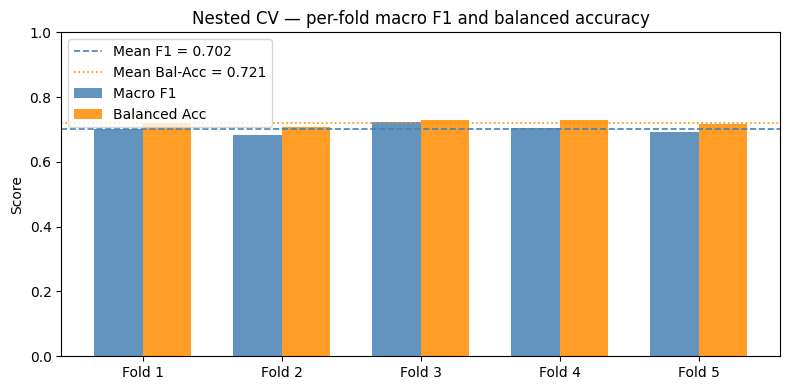

In [174]:
# ── Score bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(outer_n_splits)
width = 0.35

bars_f1  = ax.bar(x - width / 2, outer_scores_f1,      width, label="Macro F1",      color="steelblue",  alpha=0.85)
bars_bal = ax.bar(x + width / 2, outer_scores_bal_acc, width, label="Balanced Acc",  color="darkorange", alpha=0.85)

ax.axhline(np.mean(outer_scores_f1),      color="steelblue",  linestyle="--", linewidth=1.2, label=f"Mean F1 = {np.mean(outer_scores_f1):.3f}")
ax.axhline(np.mean(outer_scores_bal_acc), color="darkorange", linestyle=":",  linewidth=1.2, label=f"Mean Bal-Acc = {np.mean(outer_scores_bal_acc):.3f}")

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(outer_n_splits)])
ax.set_ylabel("Score")
ax.set_title("Nested CV — per-fold macro F1 and balanced accuracy")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [175]:
# ── Pooled classification report ────────────────────────────────────────────
all_y_true = np.concatenate([yt for yt, _ in outer_predictions])
all_y_pred = np.concatenate([yp for _, yp in outer_predictions])

print("Classification report (pooled outer test folds):\n")
print(classification_report(
    all_y_true, all_y_pred,
    target_names=le.classes_,
    digits=4,
))


Classification report (pooled outer test folds):

              precision    recall  f1-score   support

   no_points     0.8199    0.7717    0.7950       749
      podium     0.6228    0.7778    0.6917       225
      points     0.6277    0.6133    0.6204       525

    accuracy                         0.7171      1499
   macro avg     0.6901    0.7209    0.7024      1499
weighted avg     0.7230    0.7171    0.7184      1499



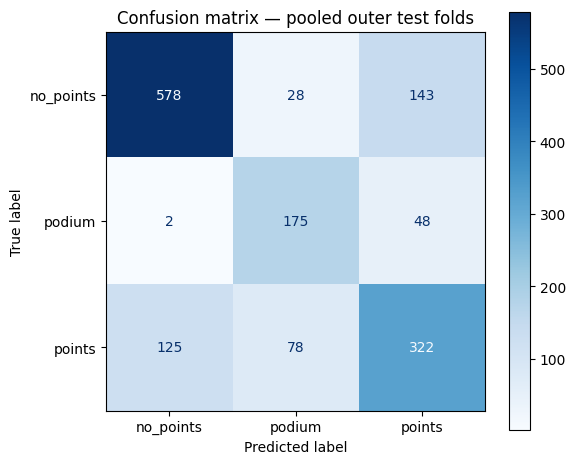

In [176]:
# ── Confusion matrix (pooled) ───────────────────────────────────────────────
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion matrix — pooled outer test folds")
plt.tight_layout()
plt.show()


# 10. Analyze Feature Importance

Feature importances are averaged across the best estimator from each outer fold. This gives a model-selection-level view of which variables were consistently useful during nested CV.


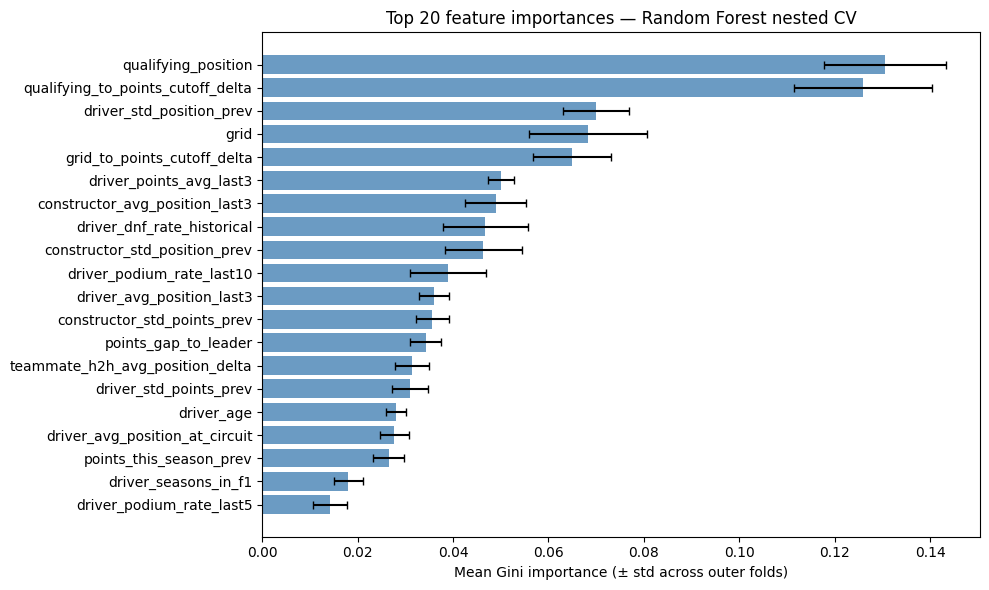

In [177]:
TOP_N = 20   # number of top features to display

importances_matrix = np.array(outer_feature_importances)   # shape (outer_folds, n_features)
mean_imp = importances_matrix.mean(axis=0)
std_imp  = importances_matrix.std(axis=0)

# Rank by mean importance, keep top N
top_idx   = np.argsort(mean_imp)[::-1][:TOP_N]
top_names = [feature_names[i] for i in top_idx]
top_mean  = mean_imp[top_idx]
top_std   = std_imp[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    y=range(TOP_N), width=top_mean[::-1],
    xerr=top_std[::-1],
    color="steelblue", alpha=0.8, capsize=3,
)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel("Mean Gini importance (± std across outer folds)")
ax.set_title(f"Top {TOP_N} feature importances — Random Forest nested CV")
plt.tight_layout()
plt.show()


# 11. Inspect Best Hyperparameters per Outer Fold

This section shows which hyperparameter configuration was selected by the inner search in each outer fold. The purpose is diagnostic: stable choices across folds suggest a more stable tuning process, while highly variable choices suggest sensitivity to the chronological training window.


In [178]:
best_params_df = pd.DataFrame(outer_best_params)
best_params_df.index = [f"Fold {i+1}" for i in range(outer_n_splits)]
best_params_df


,resampling_strategy,resampling_ratio,n_estimators,min_samples_split,min_samples_leaf,max_samples,max_features,max_depth,criterion,class_weight,bootstrap
Fold 1,None,1.0,500,10,1,0.6,0.4,NaN,log_loss,balanced,True
Fold 2,None,1.0,300,10,2,0.6,0.25,12.0,gini,balanced,True
Fold 3,None,1.0,500,10,1,0.6,sqrt,NaN,entropy,balanced,True
Fold 4,None,1.0,500,10,1,0.6,sqrt,NaN,entropy,balanced,True
Fold 5,None,1.0,500,10,2,0.6,0.4,NaN,log_loss,balanced,True


# 12. Train the Final Model and Evaluate the Untouched Holdout Test Set

After nested CV estimates model-selection performance using only the train/development data, the notebook runs one fresh hyperparameter search on the same train/development data.

The final model is then trained on the full train/development period only and evaluated once on the untouched chronological holdout test season.

The final evaluation prints:

1. Overall holdout metrics.
2. A per-label table with precision, recall, F1-score, and support for `podium`, `points`, and `no_points`.
3. A matplotlib confusion-matrix figure for the holdout set.
4. The text classification report.

The final model and its hyperparameters/metrics are saved to:

- `models_training/random-forest/rf_final_model.joblib`
- `json-parameters/random-forest/random_forest_best_params.json`


Best train/development search params:
{
  "resampling_strategy": null,
  "resampling_ratio": 1.0,
  "n_estimators": 500,
  "min_samples_split": 10,
  "min_samples_leaf": 1,
  "max_samples": 0.6,
  "max_features": "sqrt",
  "max_depth": null,
  "criterion": "entropy",
  "class_weight": "balanced",
  "bootstrap": true
}
Best train/development CV score: 0.6999

Final model trained on train/development data only.

Default argmax holdout metrics before threshold adjustment:


,metric,value
0,accuracy,0.6868
1,balanced_accuracy,0.7133
2,macro_f1,0.6865
3,weighted_f1,0.6826



Threshold-adjusted holdout metrics:


,metric,value
0,accuracy,0.6868
1,balanced_accuracy,0.7133
2,macro_precision,0.6700
3,macro_recall,0.7133
4,macro_f1,0.6865
5,weighted_precision,0.6837
6,weighted_recall,0.6868
7,weighted_f1,0.6826
8,matthews_corrcoef,0.4928
9,cohen_kappa,0.4913



Per-label holdout metrics:


,precision,recall,f1_score,support
podium,0.6702,0.8750,0.7590,72
points,0.5772,0.5119,0.5426,168
no_points,0.7627,0.7531,0.7579,239



Holdout confusion matrix table (rows=true, columns=predicted):


,pred_podium,pred_points,pred_no_points
true_podium,63,8,1
true_points,27,86,55
true_no_points,4,55,180


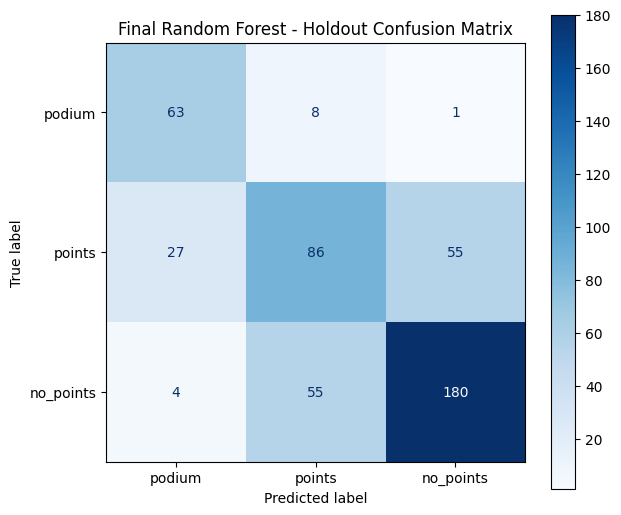


Holdout classification report:
              precision    recall  f1-score   support

      podium     0.6702    0.8750    0.7590        72
      points     0.5772    0.5119    0.5426       168
   no_points     0.7627    0.7531    0.7579       239

    accuracy                         0.6868       479
   macro avg     0.6700    0.7133    0.6865       479
weighted avg     0.6837    0.6868    0.6826       479



In [179]:
# Fresh hyperparameter search on the train/development dataset.
# The untouched holdout test set is not used for tuning.
final_search = RandomizedSearchCV(
    estimator=ResampledRandomForestClassifier(
        points_class=points_class,
        random_state=model_cfg["random_state"],
        n_jobs=model_cfg["n_jobs"],
    ),
    param_distributions=param_dist,
    n_iter=search_cfg["n_iter"],
    scoring=search_cfg["scoring"],
    cv=list(make_race_time_series_splits(df_train_dev, inner_n_splits)),
    random_state=search_cfg["random_state"],
    n_jobs=model_cfg["n_jobs"],
    refit=True,
)
final_search.fit(X_train_dev_arr, y_train_dev)
final_rf = final_search.best_estimator_
final_params = final_search.best_params_

# Evaluate once on the untouched holdout test set.
X_holdout_arr = X_holdout.values
holdout_proba = final_rf.predict_proba(X_holdout_arr)
default_holdout_pred = np.asarray(final_rf.classes_)[np.argmax(holdout_proba, axis=1)]
holdout_pred = predict_with_class_multipliers(
    holdout_proba,
    best_threshold_multipliers,
    final_rf.classes_,
)

label_order_names = ["podium", "points", "no_points"]
label_order = le.transform(label_order_names)

holdout_metrics = {
    "accuracy": accuracy_score(y_holdout, holdout_pred),
    "balanced_accuracy": balanced_accuracy_score(y_holdout, holdout_pred),
    "macro_precision": precision_score(y_holdout, holdout_pred, average="macro"),
    "macro_recall": recall_score(y_holdout, holdout_pred, average="macro"),
    "macro_f1": f1_score(y_holdout, holdout_pred, average="macro"),
    "weighted_precision": precision_score(y_holdout, holdout_pred, average="weighted"),
    "weighted_recall": recall_score(y_holdout, holdout_pred, average="weighted"),
    "weighted_f1": f1_score(y_holdout, holdout_pred, average="weighted"),
    "matthews_corrcoef": matthews_corrcoef(y_holdout, holdout_pred),
    "cohen_kappa": cohen_kappa_score(y_holdout, holdout_pred),
}

default_holdout_metrics = {
    "accuracy": accuracy_score(y_holdout, default_holdout_pred),
    "balanced_accuracy": balanced_accuracy_score(y_holdout, default_holdout_pred),
    "macro_f1": f1_score(y_holdout, default_holdout_pred, average="macro"),
    "weighted_f1": f1_score(y_holdout, default_holdout_pred, average="weighted"),
}

overall_metrics_df = pd.DataFrame(
    [(name, value) for name, value in holdout_metrics.items()],
    columns=["metric", "value"],
)
overall_metrics_df["value"] = overall_metrics_df["value"].round(4)

holdout_report = classification_report(
    y_holdout,
    holdout_pred,
    labels=label_order,
    target_names=label_order_names,
    digits=4,
    output_dict=True,
)

per_label_metrics_df = (
    pd.DataFrame(holdout_report)
    .T
    .loc[label_order_names, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1_score"})
)
per_label_metrics_df[["precision", "recall", "f1_score"]] = per_label_metrics_df[
    ["precision", "recall", "f1_score"]
].round(4)
per_label_metrics_df["support"] = per_label_metrics_df["support"].astype(int)

holdout_cm = confusion_matrix(y_holdout, holdout_pred, labels=label_order)
holdout_cm_df = pd.DataFrame(
    holdout_cm,
    index=[f"true_{name}" for name in label_order_names],
    columns=[f"pred_{name}" for name in label_order_names],
)

print("Best train/development search params:")
print(json.dumps(final_params, indent=2))
print(f"Best train/development CV score: {final_search.best_score_:.4f}")
print("\nFinal model trained on train/development data only.")

print("\nDefault argmax holdout metrics before threshold adjustment:")
display(pd.DataFrame([(name, round(value, 4)) for name, value in default_holdout_metrics.items()], columns=["metric", "value"]))

print("\nThreshold-adjusted holdout metrics:")
display(overall_metrics_df)

print("\nPer-label holdout metrics:")
display(per_label_metrics_df)

print("\nHoldout confusion matrix table (rows=true, columns=predicted):")
display(holdout_cm_df)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=holdout_cm,
    display_labels=label_order_names,
)
disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Final Random Forest - Holdout Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

print("\nHoldout classification report:")
print(classification_report(
    y_holdout,
    holdout_pred,
    labels=label_order,
    target_names=label_order_names,
    digits=4,
))


In [180]:
# Save the trained final model.
output_cfg = config.get("output", {})
MODEL_PATH = pathlib.Path(output_cfg.get("model_path", "models_training/random-forest/rf_final_model.joblib"))
if not MODEL_PATH.is_absolute():
    MODEL_PATH = REPO_ROOT / MODEL_PATH
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

model_artifact = {
    "model": final_rf,
    "onehot_encoder": onehot_encoder,
    "raw_feature_names": raw_feature_names,
    "numeric_feature_names": numeric_cols,
    "categorical_feature_names": categorical_cols,
    "encoded_feature_names": feature_names,
    "label_encoder": le,
    "threshold_multipliers": best_threshold_multipliers_by_name,
}
joblib.dump(model_artifact, MODEL_PATH)
print(f"Model artifact saved to: {MODEL_PATH}")

# Save best params and metrics to JSON.
BEST_PARAMS_PATH = pathlib.Path(output_cfg.get("best_params_path", "json-parameters/random-forest/random_forest_best_optimization_params.json"))
if not BEST_PARAMS_PATH.is_absolute():
    BEST_PARAMS_PATH = REPO_ROOT / BEST_PARAMS_PATH
BEST_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
output_record = {
    "dataset_path": str(DATA_PATH.relative_to(REPO_ROOT) if DATA_PATH.is_relative_to(REPO_ROOT) else DATA_PATH),
    "year_filter": {
        "start_year": start_year,
        "end_year": end_year,
    },
    "features_used": feature_names,
    "raw_features_used": raw_feature_names,
    "categorical_features_encoded": categorical_cols,
    "features_excluded": excluded_cols,
    "holdout_split": {
        "train_development_years": sorted(int(year) for year in df_train_dev["year"].unique()),
        "holdout_test_years": test_years,
        "excluded_years": exclude_years,
        "train_development_rows": int(len(df_train_dev)),
        "holdout_test_rows": int(len(df_holdout)),
        "train_development_races": int(df_train_dev["raceId"].nunique()),
        "holdout_test_races": int(df_holdout["raceId"].nunique()),
    },
    "nested_cv_summary": {
        "outer_folds"         : outer_n_splits,
        "inner_folds"         : inner_n_splits,
        "mean_macro_f1"       : round(float(np.mean(outer_scores_f1)), 4),
        "std_macro_f1"        : round(float(np.std(outer_scores_f1)), 4),
        "mean_balanced_acc"   : round(float(np.mean(outer_scores_bal_acc)), 4),
        "std_balanced_acc"    : round(float(np.std(outer_scores_bal_acc)), 4),
    },
    "final_search_summary": {
        "search_method"      : "RandomizedSearchCV",
        "n_iter"             : search_cfg["n_iter"],
        "scoring"            : search_cfg["scoring"],
        "cv_folds"           : inner_n_splits,
        "best_cv_score"      : round(float(final_search.best_score_), 4),
    },
    "threshold_adjustment": {
        "enabled": bool(threshold_cfg.get("enabled", False)),
        "best_multipliers": best_threshold_multipliers_by_name,
        "top_candidates": threshold_summary_df.head(10).to_dict(orient="records") if threshold_summary_df is not None else [],
    },
    "default_holdout_metrics_before_threshold": {
        name: round(float(value), 4) for name, value in default_holdout_metrics.items()
    },
    "final_holdout_metrics": {
        name: round(float(value), 4) for name, value in holdout_metrics.items()
    },
    "final_holdout_per_label_metrics": per_label_metrics_df.to_dict(orient="index"),
    "final_holdout_classification_report": holdout_report,
    "final_holdout_confusion_matrix": {
        "labels": label_order_names,
        "matrix": holdout_cm.tolist(),
    },
    "final_hyperparameters": final_params,
    "model_path": str(MODEL_PATH.relative_to(REPO_ROOT) if MODEL_PATH.is_relative_to(REPO_ROOT) else MODEL_PATH),
    "fixed_model_settings": {
        "class_weight" : model_cfg["class_weight"],
        "random_state" : model_cfg["random_state"],
    },
}

with open(BEST_PARAMS_PATH, "w") as f:
    json.dump(output_record, f, indent=2, default=str)

print(f"Best params and metrics saved to: {BEST_PARAMS_PATH}")
print(json.dumps(output_record, indent=2, default=str))


Model artifact saved to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/models_training/random-forest/rf_final_model_cutoff_delta.joblib
Best params and metrics saved to: /Users/khaido/Pisa/Data Mining/project/formula1_data_mining_project/json-parameters/random-forest/random_forest_best_cutoff_delta_params.json
{
  "dataset_path": "dataset/outputs/prediction.csv",
  "year_filter": {
    "start_year": null,
    "end_year": null
  },
  "features_used": [
    "grid",
    "qualifying_position",
    "grid_to_points_cutoff_delta",
    "qualifying_to_points_cutoff_delta",
    "driver_age",
    "driver_std_points_prev",
    "driver_std_position_prev",
    "constructor_std_points_prev",
    "constructor_std_position_prev",
    "points_this_season_prev",
    "driver_avg_position_last3",
    "driver_podium_rate_last3",
    "driver_podium_rate_last5",
    "driver_podium_rate_last10",
    "driver_points_avg_last3",
    "constructor_avg_position_last3",
    "driver_wins_at_circu

# 13. Summary

| Item | Choice | Reason |
|---|---|---|
| Final holdout | Configured by `data.holdout.test_years` | Gives one untouched final test score |
| Split strategy | Race-level `TimeSeriesSplit` inside train/development data | Prevents future-race leakage and keeps whole races together |
| Shuffle | No | Chronological order must be preserved |
| Outer folds | 5 | Gives independent validation windows inside the training period |
| Inner folds | 3 | Balances tuning stability and runtime |
| Search method | `RandomizedSearchCV` | Efficient over the large parameter space |
| Scoring | Macro F1 | Penalizes ignoring minority classes |
| `class_weight` | `"balanced"` | Compensates for target imbalance |
| Final model | Trained on train/development data only | Keeps the holdout test season untouched for final accuracy and F1 |

Key files produced:

- `json-parameters/random-forest/random_forest_params.json`: input search and holdout configuration.
- `json-parameters/random-forest/random_forest_best_params.json`: nested CV summary, final holdout metrics, per-label metrics, confusion matrix, and final hyperparameters.
- `models_training/random-forest/rf_final_model.joblib`: serialized final model trained before the holdout period.
